In [ ]:
# ==============================
# SVM – IRIS DATASET
# ==============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
iris = pd.read_csv('/content/iris (1) (1).csv')

# Features and target
X = iris.drop('species', axis=1)
y = iris['species']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ------------------------------
# 1. Linear Kernel
# ------------------------------
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("=== IRIS - LINEAR KERNEL ===")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))

# ------------------------------
# 2. RBF Kernel
# ------------------------------
rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

print("\n=== IRIS - RBF KERNEL ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

=== IRIS - LINEAR KERNEL ===
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

=== IRIS - RBF KERNEL ===
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


=== LETTER DATASET ===
Accuracy: 0.9305
Confusion Matrix:
 [[144   0   1   0   0   0   1   0   0   0   1   0   1   0   0   0   0   0
    0   0   1   0   0   0   0   0]
 [  0 143   0   5   0   1   0   0   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [  0   0 123   0   2   0   3   1   0   0   1   0   0   0   4   0   0   2
    0   0   1   0   0   0   0   0]
 [  0   1   0 153   0   0   0   2   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   1   0 130   0   5   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   2   0   0   1 134   0   0   1   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   0   0   0]
 [  1   0   1   4   0   0 149   0   0   0   2   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   4   0   8   0   0   0 106   0   0   5   0   0   1   2   1   1  13
    0   0   2   0   0   0   1   0]
 [  0   0   0   1   0   2   0   0 134   7   0   0   0   0   0   0   0

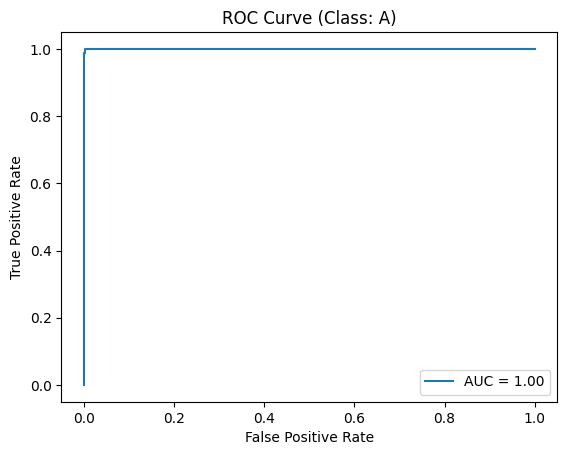

AUC for class A : 0.9999390030306781


In [ ]:
# ==============================
# SVM – LETTER RECOGNITION
# ==============================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

# Load dataset
letter = pd.read_csv('/content/letter-recognition.csv')

# Features and target
X = letter.drop('letter', axis=1)
y = letter['letter']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train SVM (RBF kernel)
model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("=== LETTER DATASET ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ------------------------------
# ROC Curve & AUC (One-vs-Rest)
# ------------------------------
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)

y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(lb.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC for first class (example)
plt.figure()
plt.plot(fpr[0], tpr[0], label="AUC = %0.2f" % roc_auc[0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Class: " + lb.classes_[0] + ")")
plt.legend(loc="lower right")
plt.show()

print("AUC for class", lb.classes_[0], ":", roc_auc[0])